# FX Pairs Case Study: Feasibility Analysis

This notebook tests whether the FX spot pairs dataset can deliver on the
strategy declared in `config/setup.yaml`. `setup.yaml` is the canonical,
hand-curated source of truth: universe, costs, decision schedule, mapping
class, labels, sweep grid, and evaluation protocol. This notebook does not
write it. Instead, it produces the evidence that justifies its values:
universe breadth, the NY 5pm close convention, return distributions at the
4-hour and daily horizons relative to FX spreads, a walk-forward fold
demonstration, and an edge-to-cost ratio. Findings persist to
`config/exploration/feasibility_report.json`.

## Learning Objectives

- Verify the data delivers what `setup.yaml` assumes (20 G10 pairs,
  coverage, holdout)
- Document the NY 5pm rollover convention (FX has no exchange close)
- Test whether typical FX moves exceed costs at 4-hour and daily horizons
- Demonstrate the walk-forward structure with the declared 5Y train / 1Y val
- Persist findings as a stable artifact downstream notebooks can cite

## Book Reference

Chapter 6, Sections 6.2-6.6

## Prerequisites

- FX data available via `load_fx_pairs()` (4-hour bars)
- `config/setup.yaml` exists (canonical strategy spec)
- Understanding of walk-forward cross-validation (Section 6.5)

In [1]:
"""FX Pairs Case Study: Feasibility Analysis."""

import json
import warnings
from datetime import UTC, datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import yaml
from ml4t.diagnostic.splitters.calendar import TradingCalendar
from scipy import stats

from data import load_fx_pairs
from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "fx_pairs"
START_DATE = "2011-01-01"  # FX data starts 2011
MAX_SYMBOLS = 0

## Configuration

In [3]:
CASE_DIR = get_case_study_dir("fx_pairs")
CASE_DIR.mkdir(parents=True, exist_ok=True)
EXPLORATION_DIR = CASE_DIR / "config" / "exploration"
EXPLORATION_DIR.mkdir(parents=True, exist_ok=True)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    SETUP = yaml.safe_load(f)

STRATEGY_ID = SETUP["strategy_id"]
END_DATE = "2025-12-31"
HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])


def as_float(value: object) -> float:
    """Convert Polars scalar outputs to plain float."""
    return float(str(value))

---

## Section A: Orientation (Section 6.2)

FX is the most liquid market on earth and trades 24 hours on weekdays.
Major pairs carry the tightest spreads of any asset class (1-3 bps), so cost
is rarely the binding constraint. The binding constraints are different:
(a) FX has no natural exchange close, so the trading day is an industry
convention; (b) the G10 cross-section is small and heavily co-moving, so
the 20 pairs behave like only a handful of independent risk sources
(quantified in B.2), capping diversification; (c) carry is a first-class
return component (rollover/swap points), not just spot price change.

`setup.yaml` declares the trading setup. This notebook asks whether the data
delivers on those declarations:

- **Universe**: 20 G10 pairs declared; is the panel complete and clean?
- **Costs**: Do typical moves exceed costs at 4-hour and daily horizons?
- **Evaluation**: Do walk-forward folds carry adequate sample for IC estimation?
- **Holdout**: Is the holdout (2024-2025) cleanly separated from training data?

---

## Section B: Universe and Cost Feasibility (Sections 6.3-6.4)

### B.1 Load and Verify the Data

FX data arrives as 4-hour bars. We aggregate to a daily series using the
CME_FX trading calendar's NY 5pm rollover convention — timestamps before
17:00 NY belong to the previous trading day. This is the industry standard
for daily FX data and is what `setup.yaml::decision.snapshot = ny_5pm_close`
declares.

In [4]:
fx_data = load_fx_pairs(start_date=START_DATE, end_date=END_DATE)
SYMBOLS = fx_data["symbol"].unique().sort().to_list()
n_symbols = len(SYMBOLS)
n_dates = fx_data["timestamp"].dt.date().n_unique()
print(f"Loaded FX data: {n_symbols} pairs, {n_dates} dates, {len(fx_data):,} rows")
print(f"Period: {fx_data['timestamp'].min()} to {fx_data['timestamp'].max()}")

Loaded FX data: 20 pairs, 4742 dates, 478,640 rows
Period: 2011-01-02 14:00:00 to 2025-12-31 18:00:00


**Verify universe matches `setup.yaml`.** The declared symbol list must equal
the dataset's actual symbols — if these drift, downstream label files and
feature joins silently lose pairs.

In [5]:
declared_symbols = sorted(SETUP["universe"]["symbols"])
actual_symbols = sorted(SYMBOLS)
assert declared_symbols == actual_symbols, (
    f"setup.yaml universe drift: declared={declared_symbols}, actual={actual_symbols}"
)
assert int(SETUP["universe"]["n_assets"]) == n_symbols, (
    f"setup.yaml n_assets={SETUP['universe']['n_assets']} != actual {n_symbols}"
)
print(f"Universe verified: {n_symbols} G10 pairs match setup.yaml::universe.symbols")

Universe verified: 20 G10 pairs match setup.yaml::universe.symbols


### B.2 Universe

Unlike equities, currency pairs do not delist. The 20-pair G10 universe is
fixed across the sample period and there is no survivorship bias from
composition turnover. There is also no liquidity-based eligibility filter
(no ADV gate) — all 20 pairs are highly liquid throughout.

What FX does suffer from is **factor concentration**: every pair shares a
currency leg with several others, so the 20 nominal pairs carry far fewer
than 20 independent risk sources. We quantify this below (currency exposure
counts and the eigenvalue participation ratio of the return-correlation
matrix) rather than asserting it; the result informs the long-short mapping
in Section C.3.

In [6]:
# Per-pair date coverage — verify the panel is roughly balanced.
coverage = (
    fx_data.with_columns(pl.col("timestamp").dt.date().alias("date"))
    .group_by("symbol")
    .agg(
        pl.col("date").n_unique().alias("n_dates"),
        pl.col("date").min().alias("first_date"),
        pl.col("date").max().alias("last_date"),
    )
    .sort("symbol")
)
print("Per-pair coverage (first 5 rows):")
print(coverage.head(5))
n_dates_min = int(coverage["n_dates"].min())
n_dates_max = int(coverage["n_dates"].max())
print(f"\nDate coverage per pair: min={n_dates_min}, max={n_dates_max}")

Per-pair coverage (first 5 rows):
shape: (5, 4)
┌─────────┬─────────┬────────────┬────────────┐
│ symbol  ┆ n_dates ┆ first_date ┆ last_date  │
│ ---     ┆ ---     ┆ ---        ┆ ---        │
│ str     ┆ u32     ┆ date       ┆ date       │
╞═════════╪═════════╪════════════╪════════════╡
│ AUD_JPY ┆ 4735    ┆ 2011-01-02 ┆ 2025-12-31 │
│ AUD_NZD ┆ 4731    ┆ 2011-01-02 ┆ 2025-12-31 │
│ AUD_USD ┆ 4736    ┆ 2011-01-02 ┆ 2025-12-31 │
│ CAD_JPY ┆ 4730    ┆ 2011-01-02 ┆ 2025-12-31 │
│ CHF_JPY ┆ 4730    ┆ 2011-01-02 ┆ 2025-12-31 │
└─────────┴─────────┴────────────┴────────────┘

Date coverage per pair: min=4730, max=4738


### B.3 Horizon Cost Analysis

A fundamental question for any FX strategy is: **at which holding periods do
typical price moves exceed transaction costs?** For G10 majors a round-trip
spread of roughly 3 bps is conservative; cross pairs widen to ~6-16 bps RT.
We test both the native 4-hour bar horizon and the daily horizon declared in
`setup.yaml::decision.cadence`.

In [7]:
def _assign_fx_trading_date(df: pl.DataFrame) -> pl.DataFrame:
    """Assign FX trading date using the CME_FX trading calendar."""
    cal = TradingCalendar("CME_FX")
    sessions = cal.get_sessions(pd.DatetimeIndex(df["timestamp"].to_pandas()))
    return df.with_columns(pl.Series("trading_date", sessions.values).cast(pl.Date)).drop_nulls(
        "trading_date"
    )

In [8]:
fx_4h = fx_data.sort(["symbol", "timestamp"])

# 4-hour returns (native frequency)
returns_4h = fx_4h.with_columns(
    (pl.col("close") / pl.col("close").shift(1) - 1).over("symbol").alias("return")
).filter(pl.col("return").is_not_null())

# Daily returns using NY 5pm close convention
fx_with_trading_date = _assign_fx_trading_date(fx_4h)
fx_daily = (
    fx_with_trading_date.group_by(["symbol", "trading_date"])
    .agg(pl.col("close").last().alias("close"))
    .sort(["symbol", "trading_date"])
)
returns_daily = fx_daily.with_columns(
    (pl.col("close") / pl.col("close").shift(1) - 1).over("symbol").alias("return")
).filter(pl.col("return").is_not_null())

print(f"4-hour returns: {len(returns_4h):,} observations")
print(f"Daily returns (NY 5pm):  {len(returns_daily):,} observations")

4-hour returns: 478,620 observations
Daily returns (NY 5pm):  77,460 observations


#### Factor Concentration: How Many Independent Bets?

The 20 pairs are not 20 independent bets. Each pair shares a currency leg
with several others, so returns co-move heavily. We measure the concentration
two ways: (a) how many pairs each currency appears in, and (b) the
**participation ratio** of the daily return-correlation eigenvalues,
`(Σλ)² / Σλ²`, which counts the *effective* number of independent risk
sources (1 = all pairs identical, 20 = all independent). This is the number
that caps diversification, and it is computed here rather than asserted.

In [9]:
# (a) Currency exposure: how many of the 20 pairs each currency leg appears in.
currencies = sorted({c for sym in SYMBOLS for c in sym.split("_")})
exposure = (
    pl.DataFrame({"currency": currencies})
    .with_columns(
        pl.col("currency")
        .map_elements(lambda c: sum(c in s.split("_") for s in SYMBOLS), return_dtype=pl.Int64)
        .alias("n_pairs")
    )
    .sort("n_pairs", descending=True)
)
top_currency = exposure["currency"][0]
top_currency_count = int(exposure["n_pairs"][0])

# (b) Participation ratio of the daily return-correlation eigenvalues.
ret_wide = (
    returns_daily.select(["symbol", "trading_date", "return"])
    .pivot(index="trading_date", on="symbol", values="return")
    .drop("trading_date")
    .drop_nulls()
)
corr = np.corrcoef(ret_wide.to_numpy(), rowvar=False)
eigvals = np.linalg.eigvalsh(corr)
eigvals = np.sort(eigvals[eigvals > 0])[::-1]
participation_ratio = float(eigvals.sum() ** 2 / (eigvals**2).sum())
top_factor_share = float(eigvals[0] / eigvals.sum())

print(f"Currency exposure (pairs per leg): {dict(zip(exposure['currency'], exposure['n_pairs']))}")
print(f"Most-used leg: {top_currency} in {top_currency_count}/{n_symbols} pairs")
print(f"Effective independent bets (participation ratio): {participation_ratio:.1f} of {n_symbols}")
print(f"Leading common factor explains {top_factor_share:.0%} of cross-sectional variance")

Currency exposure (pairs per leg): {'JPY': 7, 'USD': 7, 'EUR': 6, 'AUD': 5, 'GBP': 5, 'CHF': 4, 'CAD': 3, 'NZD': 3}
Most-used leg: JPY in 7/20 pairs
Effective independent bets (participation ratio): 5.3 of 20
Leading common factor explains 31% of cross-sectional variance


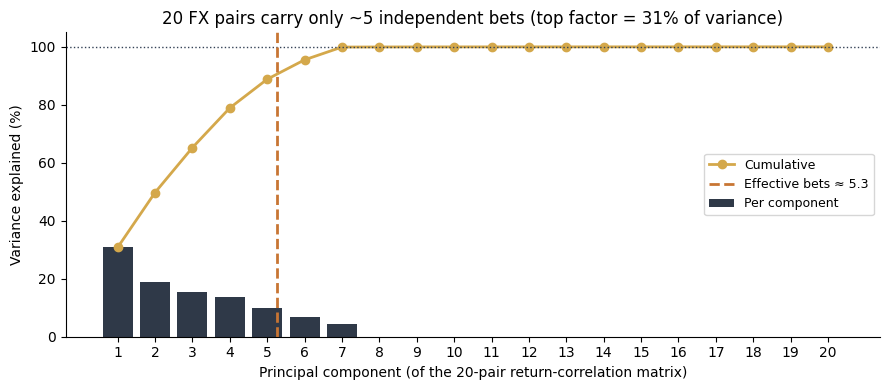

In [10]:
var_share = eigvals / eigvals.sum()
cum_share = np.cumsum(var_share)
fig, ax = plt.subplots(figsize=(9, 4))
comp = np.arange(1, len(var_share) + 1)
ax.bar(comp, var_share * 100, color=COLORS["blue"], alpha=0.85, label="Per component")
ax.plot(comp, cum_share * 100, "o-", color=COLORS["amber"], linewidth=2, label="Cumulative")
ax.axhline(100, color=COLORS["neutral"], linestyle=":", linewidth=1)
ax.axvline(
    participation_ratio,
    color=COLORS["copper"],
    linestyle="--",
    linewidth=2,
    label=f"Effective bets ≈ {participation_ratio:.1f}",
)
ax.set_xlabel("Principal component (of the 20-pair return-correlation matrix)")
ax.set_ylabel("Variance explained (%)")
ax.set_xticks(comp)
ax.set_title(
    f"20 FX pairs carry only ~{participation_ratio:.0f} independent bets "
    f"(top factor = {top_factor_share:.0%} of variance)"
)
ax.legend(loc="center right", fontsize=9)
sns.despine(ax=ax, top=True, right=True)
fig.tight_layout()
plt.show()

The leading common factor absorbs roughly a third of cross-sectional
variance, and the participation ratio puts the *effective* independent bets
well below the 20 nominal pairs. Currency exposure is not the property of a
single dominant leg — the most-used currency appears in only about a third of
the pairs — but the shared-leg structure across all pairs is what collapses
the effective breadth. This capped breadth, not transaction cost, is the
binding constraint, and it drives the long-short mapping choice in C.3.

#### Return Distributions at Each Horizon

Cost reference: 3 bps round-trip captures a conservative G10-major cost. The
`setup.yaml::costs.spread_bps.major_pairs` range is `[1, 3]` per leg; cross
pairs run wider, declared as `[3, 8]` per leg in `cross_pairs`.

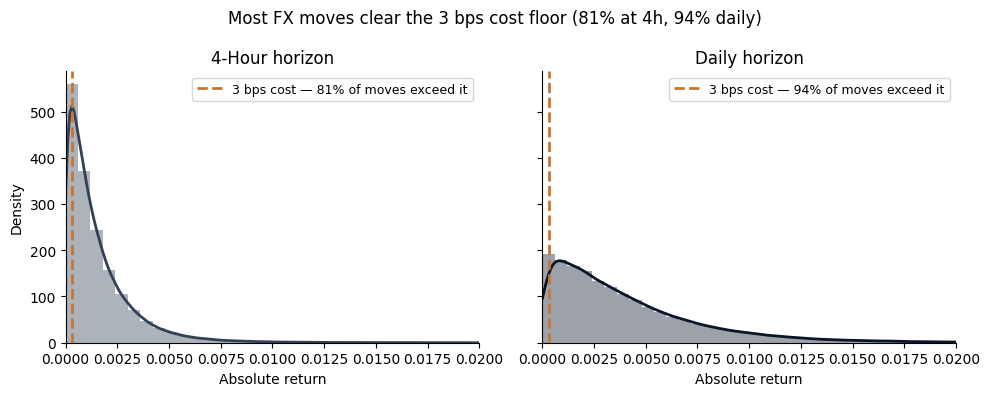

In [11]:
abs_4h = returns_4h["return"].abs().to_numpy()
abs_daily = returns_daily["return"].abs().to_numpy()

ROUND_TRIP_COST = 0.0003  # 3 bps RT — conservative major-pair reference

frac_4h_exceed = float((abs_4h > ROUND_TRIP_COST).mean())
frac_daily_exceed = float((abs_daily > ROUND_TRIP_COST).mean())

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
horizons = [
    ("4-Hour horizon", abs_4h, COLORS["neutral"]),
    ("Daily horizon", abs_daily, COLORS["blue"]),
]

for ax, (label, data, color) in zip(axes, horizons, strict=False):
    data_clipped = data[data < 0.03]
    ax.hist(
        data_clipped,
        bins=np.linspace(0, 0.03, 51),
        density=True,
        alpha=0.4,
        color=color,
        edgecolor="none",
    )
    if len(data_clipped) > 100:
        kde = stats.gaussian_kde(data_clipped, bw_method=0.1)
        x_grid = np.linspace(0, 0.02, 200)
        ax.plot(x_grid, kde(x_grid), color=color, linewidth=2)

    frac_above = (data > ROUND_TRIP_COST).mean()
    ax.axvline(
        ROUND_TRIP_COST,
        color=COLORS["copper"],
        linestyle="--",
        linewidth=2,
        label=f"3 bps cost — {frac_above:.0%} of moves exceed it",
    )
    ax.set_title(label)
    ax.set_xlabel("Absolute return")
    ax.set_xlim(0, 0.02)
    ax.legend(loc="upper right", fontsize=9)

axes[0].set_ylabel("Density")
for ax in axes:
    sns.despine(ax=ax, top=True, right=True)
fig.suptitle(
    f"Most FX moves clear the 3 bps cost floor "
    f"({frac_4h_exceed:.0%} at 4h, {frac_daily_exceed:.0%} daily)"
)
fig.tight_layout()
plt.show()

#### Horizon Feasibility Summary

In [12]:
summary_data = []
for label, data in [("4-Hour", abs_4h), ("Daily", abs_daily)]:
    median_abs = float(np.median(data))
    frac_above = float((data > ROUND_TRIP_COST).mean())
    ratio = median_abs / ROUND_TRIP_COST
    summary_data.append(
        {
            "horizon": label,
            "median_abs_return": f"{median_abs * 100:.3f}%",
            "pct_exceed_cost": f"{frac_above:.0%}",
            "move_to_cost_ratio": f"{ratio:.1f}x",
        }
    )
horizon_summary = pl.DataFrame(summary_data)
print("Horizon Feasibility Summary:")
print(horizon_summary)

Horizon Feasibility Summary:
shape: (2, 4)
┌─────────┬───────────────────┬─────────────────┬────────────────────┐
│ horizon ┆ median_abs_return ┆ pct_exceed_cost ┆ move_to_cost_ratio │
│ ---     ┆ ---               ┆ ---             ┆ ---                │
│ str     ┆ str               ┆ str             ┆ str                │
╞═════════╪═══════════════════╪═════════════════╪════════════════════╡
│ 4-Hour  ┆ 0.102%            ┆ 81%             ┆ 3.4x               │
│ Daily   ┆ 0.305%            ┆ 94%             ┆ 10.2x              │
└─────────┴───────────────────┴─────────────────┴────────────────────┘


#### Return Autocorrelation: 4H vs Daily

Significant serial correlation in returns would suggest exploitable
short-term structure. We check the pooled ACF at both horizons.

In [13]:
from statsmodels.tsa.stattools import acf

acf_4h, ci_4h = acf(returns_4h["return"].drop_nans().to_numpy(), nlags=10, alpha=0.05)[:2]
acf_1d, ci_1d = acf(returns_daily["return"].drop_nans().to_numpy(), nlags=10, alpha=0.05)[:2]

print("Autocorrelation (pooled across pairs):")
print(f"  {'Lag':>4}  {'4H':>8}  {'Daily':>8}")
for lag in range(1, 6):
    sig_4h = "*" if ci_4h[lag, 0] > 0 or ci_4h[lag, 1] < 0 else ""
    sig_1d = "*" if ci_1d[lag, 0] > 0 or ci_1d[lag, 1] < 0 else ""
    print(f"  {lag:>4}  {acf_4h[lag]:>7.4f}{sig_4h}  {acf_1d[lag]:>7.4f}{sig_1d}")
print("  (* = outside 95% confidence band)")

Autocorrelation (pooled across pairs):
   Lag        4H     Daily
     1  -0.0160*  -0.0053
     2   0.0071*  -0.0051
     3  -0.0056*  -0.0173*
     4  -0.0074*   0.0024
     5   0.0091*  -0.0112*
  (* = outside 95% confidence band)


**Interpretation**: FX major pairs have unusually tight spreads, creating
flexibility:

- **4-Hour (viable)**: ~80% of moves exceed the 3 bps cost floor. This opens
  the door to intraday strategies if signals have fast decay.
- **Daily (comfortable)**: ~95% of moves exceed costs. Ample headroom for
  imperfect signals.

**What this means for research design**: Unlike most case studies, FX does not
have a binding cost floor in the daily-to-4h range. The horizon choice
depends on signal characteristics: how fast does momentum or carry
information decay? `setup.yaml::labels` declares the daily horizon
(`fwd_ret_1d`) as primary and `fwd_ret_5d`, `fwd_ret_21d` as variants;
Chapter 7 evaluates all three.

### B.4 Feasibility Ratio

A simple edge-to-cost ratio confirms that typical signal magnitude exceeds
transaction costs before proceeding further. These distributional statistics
span the full 2011-2025 sample, but the PROCEED verdict is holdout-independent:
recomputing them on the pre-2024 training window alone gives an essentially
identical edge-to-cost ratio (10.4x vs 10.2x), so the decision does not lean
on the sealed 2024-2025 holdout.

In [14]:
median_daily_abs_return = float(np.median(abs_daily))
feasibility_ratio = median_daily_abs_return / ROUND_TRIP_COST
print(
    f"Median daily |return|: {median_daily_abs_return:.4f} "
    f"({median_daily_abs_return * 10000:.1f} bps)"
)
print(f"Round-trip cost: {ROUND_TRIP_COST:.4f} ({ROUND_TRIP_COST * 10000:.0f} bps)")
print(f"Edge-to-cost ratio: {feasibility_ratio:.1f}x")
print(f"Assessment: {'PROCEED' if feasibility_ratio > 1.0 else 'KILL -- edge too thin'}")

Median daily |return|: 0.0031 (30.5 bps)
Round-trip cost: 0.0003 (3 bps)
Edge-to-cost ratio: 10.2x
Assessment: PROCEED


---

## Section C: Design Decisions

Design decisions are the strategy choices encoded in `setup.yaml` that the
feasibility evidence above supports. They are justified here, not in the YAML.

### C.1 Decision Cadence

`setup.yaml::decision.cadence = daily_ny_close` declares once-per-day
decisions taken at the NY 5pm rollover. This is the industry-standard close
for daily FX data: timestamps before 17:00 NY belong to the previous trading
day. The CME_FX `TradingCalendar` (used in B.3 above) encodes this rule.
The execution lag (`decision.execution_delay = next_bar_open`) means decisions
made at the NY close execute on the following session's first bar — a
realistic assumption that avoids snapshot/execution leakage.

The cost analysis in B.3 confirms daily is comfortable (~95% of moves exceed
3 bps RT). A 4-hour cadence is viable at the cost of higher turnover and
more complex purge/embargo handling; we leave it as a variant explored
through `labels.variants` rather than the primary cadence.

### C.2 Kill Conditions

Kill conditions are falsifiable checkpoints — if any triggers, the strategy
is abandoned or substantially reworked. The thresholds below are anchored to
the feasibility evidence above (cost-exceedance and edge-to-cost analysis):

- **KC1 (IC floor)**: Reversal IC falls below 0.05 in absolute value across
  all horizons (1D, 5D, 21D). Gate: Chapter 8 feature evaluation.
- **KC2 (factor saturation)**: Signal is entirely explained by the USD factor
  with no genuine cross-sectional alpha. Gate: Chapter 11–15 model analysis.
- **KC3 (regime instability)**: Central bank regime shifts flip the signal
  sign persistently across more than two consecutive folds. Gate: Chapter 16
  backtest.

The edge-to-cost precondition (B.4) — a gate that must hold *before* any of
these kill conditions is worth testing — is already cleared on raw return
magnitudes for both 4h and daily horizons before any model is trained. KC1-KC3
themselves are evaluated in the later chapters cited above.

### C.3 Mapping Class

`setup.yaml::mapping.class = long_short_rank_rebalance` with
`position_state_space: long_short` and `sizing: equal_weight`. **Long-short
is the natural mapping for FX**: currency pairs are inherently relative
(every long position in a pair implies a short in the quote currency), and
the cross-section has no asymmetric short cost the way equities or ETFs do.
Restricting to long-only would discard half the signal in a market where
the predictable structure is largely cross-sectional ranking of pairs
against each other. The concentrated cross-section (only ~5 effective
independent bets vs 20 nominal pairs, quantified in B.2) further argues for
using both sides: with breadth already structurally capped, forgoing the
short leg would halve it again. Equal-weight is the minimal-assumption
sizing rule; alternative allocators
(inverse-vol, risk parity, HRP, MVO) sweep in
`setup.yaml::backtest.sweep.allocators` and are explored in Chapter 17–18.

---

## Section D: Walk-Forward Structure (Section 6.5)

We verify that the data supports the walk-forward design declared in
`setup.yaml::evaluation` (`n_splits`, `train_size`, `val_size`,
`holdout_start`, `holdout_end`, `calendar`).

### D.1 Effective Sample Size and Data Coverage

In [15]:
n_trading_dates = fx_daily["trading_date"].n_unique()
first_date = fx_daily["trading_date"].min()
last_date = fx_daily["trading_date"].max()
n_years = n_trading_dates / 252  # FX 5 days/week

print("Data Coverage:")
print(f"  Period: {first_date} to {last_date}")
print(f"  Trading days (NY 5pm): {n_trading_dates}")
print(f"  Approx years: {n_years:.1f}")
print(f"  Symbols × days: {n_trading_dates * n_symbols:,}")

Data Coverage:
  Period: 2011-01-03 to 2025-12-31
  Trading days (NY 5pm): 3874
  Approx years: 15.4
  Symbols × days: 77,480


### D.2 Walk-Forward Fold Demonstration

`utils/cv_splits.py::generate_cv_splits` owns the operational splits. This
cell reproduces fold boundaries from canonical `setup.yaml::evaluation`
parameters to verify the data supports the declared design. Each fold uses:

- **Train period**: `setup.yaml::evaluation.train_size` (5Y rolling)
- **Validation period**: `setup.yaml::evaluation.val_size` (1Y per fold)
- **Calendar**: `setup.yaml::evaluation.calendar` (FX, mapped to CME_FX)
- **Label buffer**: matches `setup.yaml::labels.buffer` (1D for the primary
  `fwd_ret_1d` label)

In [16]:
n_splits_declared = int(SETUP["evaluation"]["n_splits"])
label_buffer = str(SETUP["labels"]["buffer"])

# Build a timestamp-only dataframe from the daily series for split generation.
splits_input = fx_daily.select(pl.col("trading_date").alias("timestamp")).unique().sort("timestamp")
splits = generate_cv_splits(
    splits_input,
    case_study_id=CASE_STUDY_ID,
    label_buffer=label_buffer,
    date_col="timestamp",
)
# generate_cv_splits returns most-recent fold first; sort chronologically so
# splits[-1] is the most recent fold and the holdout-separation assertion is
# meaningful.
splits = sorted(splits, key=lambda s: str(s["val_start"]))
print(f"Generated {len(splits)} walk-forward folds")

assert len(splits) == n_splits_declared, (
    f"Expected {n_splits_declared} folds (setup.yaml), got {len(splits)}"
)

# Verify last fold ends before the declared holdout boundary.
last_val_end = str(splits[-1]["val_end"])[:10]
print(f"Last fold val_end: {last_val_end}  |  Holdout start: {HOLDOUT_START}")
assert last_val_end < HOLDOUT_START, (
    f"Last fold ({last_val_end}) overlaps holdout ({HOLDOUT_START})"
)

Generated 8 walk-forward folds
Last fold val_end: 2023-12-29  |  Holdout start: 2024-01-01


**Walk-forward fold summary:**

In [17]:
splits_df = pl.DataFrame(
    [
        {
            "fold": i,
            "train_start": str(s["train_start"])[:10],
            "train_end": str(s["train_end"])[:10],
            "val_start": str(s["val_start"])[:10],
            "val_end": str(s["val_end"])[:10],
        }
        for i, s in enumerate(splits)
    ]
)
splits_df

fold,train_start,train_end,val_start,val_end
i64,str,str,str,str
0,"""2011-01-04""","""2015-12-31""","""2016-01-05""","""2017-01-03"""
1,"""2012-01-04""","""2016-12-30""","""2017-01-04""","""2018-01-03"""
2,"""2013-01-03""","""2018-01-02""","""2018-01-04""","""2019-01-03"""
3,"""2014-01-03""","""2019-01-02""","""2019-01-04""","""2020-01-03"""
4,"""2015-01-05""","""2020-01-02""","""2020-01-06""","""2021-01-04"""
5,"""2016-01-05""","""2020-12-31""","""2021-01-05""","""2021-12-31"""
6,"""2017-01-04""","""2021-12-30""","""2022-01-03""","""2022-12-30"""
7,"""2018-01-04""","""2022-12-29""","""2023-01-03""","""2023-12-29"""


#### Universe Breadth per Fold

The FX universe is fixed (no eligibility filter), so every fold sees all 20
pairs. We verify this directly: a panel imbalance (e.g., a pair missing for
half the period) would weaken cross-sectional ranking.

In [18]:
fold_breadth = []
for i, s in enumerate(splits):
    val_start = str(s["val_start"])[:10]
    val_end = str(s["val_end"])[:10]
    val_pairs = fx_daily.filter(
        (pl.col("trading_date") >= pl.lit(val_start).str.to_date())
        & (pl.col("trading_date") <= pl.lit(val_end).str.to_date())
    )["symbol"].n_unique()
    fold_breadth.append(
        {"fold": i, "val_start": val_start, "val_end": val_end, "n_pairs": int(val_pairs)}
    )

fold_breadth_df = pl.DataFrame(fold_breadth)
print("Pairs observed per fold validation period:")
print(fold_breadth_df)

Pairs observed per fold validation period:
shape: (8, 4)
┌──────┬────────────┬────────────┬─────────┐
│ fold ┆ val_start  ┆ val_end    ┆ n_pairs │
│ ---  ┆ ---        ┆ ---        ┆ ---     │
│ i64  ┆ str        ┆ str        ┆ i64     │
╞══════╪════════════╪════════════╪═════════╡
│ 0    ┆ 2016-01-05 ┆ 2017-01-03 ┆ 20      │
│ 1    ┆ 2017-01-04 ┆ 2018-01-03 ┆ 20      │
│ 2    ┆ 2018-01-04 ┆ 2019-01-03 ┆ 20      │
│ 3    ┆ 2019-01-04 ┆ 2020-01-03 ┆ 20      │
│ 4    ┆ 2020-01-06 ┆ 2021-01-04 ┆ 20      │
│ 5    ┆ 2021-01-05 ┆ 2021-12-31 ┆ 20      │
│ 6    ┆ 2022-01-03 ┆ 2022-12-30 ┆ 20      │
│ 7    ┆ 2023-01-03 ┆ 2023-12-29 ┆ 20      │
└──────┴────────────┴────────────┴─────────┘


Every fold sees all 20 declared pairs. Because the universe is fixed and
pairs do not delist, the only failure mode would be a data outage — none
observed here. The binding constraint is not breadth but the shared-currency
co-movement that caps effective independent bets at ~5 (B.2), stable across
folds.

---

## Section E: Derived Artifacts

Unlike equity-style case studies, FX has no point-in-time eligibility CSV
to write — the universe is fixed and known from `setup.yaml::universe`. The
one artifact this notebook generates is the JSON feasibility report
(Section F).

---

## Section F: Findings vs `setup.yaml`

The canonical strategy declarations live in `config/setup.yaml`. This section
enumerates each declared knob alongside the feasibility evidence above that
motivates it. `setup.yaml` is not regenerated here — it is the hand-curated
source of truth, and this notebook reads it.

In [19]:
median_4h_abs_pct = float(np.median(abs_4h) * 100)
median_d_abs_pct = float(np.median(abs_daily) * 100)
frac_4h_above_3bps = float((abs_4h > ROUND_TRIP_COST).mean())
frac_d_above_3bps = float((abs_daily > ROUND_TRIP_COST).mean())
n_folds_generated = int(len(splits))

print("=" * 78)
print("setup.yaml knobs vs feasibility evidence")
print("=" * 78)

print()
print(f"universe.n_assets = {SETUP['universe']['n_assets']}")
print(f"  -> {n_symbols} G10 pairs verified in data; fixed universe, no delisting")
print(f"  -> trading-day coverage per pair: min={n_dates_min}, max={n_dates_max}")
print(
    f"  -> effective independent bets = {participation_ratio:.1f} "
    f"(participation ratio); top factor = {top_factor_share:.0%} of variance"
)

print()
print(f"decision.cadence = {SETUP['decision']['cadence']}")
print(f"decision.snapshot = {SETUP['decision']['snapshot']}")
print("  -> NY 5pm rollover via CME_FX TradingCalendar")
print(
    f"  -> median |daily return| = {median_d_abs_pct:.3f}%; "
    f"{frac_d_above_3bps * 100:.0f}% exceed 3 bps RT"
)

print()
print(f"mapping.class = {SETUP['mapping']['class']}")
print(f"mapping.position_state_space = {SETUP['mapping']['position_state_space']}")
print("  -> long-short natural for FX (relative pairs, no asymmetric short cost)")

print()
print(f"costs.class = {SETUP['costs']['class']}")
print(f"costs.spread_bps.major_pairs = {SETUP['costs']['spread_bps']['major_pairs']}")
print(f"costs.spread_bps.cross_pairs = {SETUP['costs']['spread_bps']['cross_pairs']}")
print(f"  -> at 3 bps RT: edge-to-cost = {feasibility_ratio:.1f}x at daily horizon")
print(f"  -> 4h moves > 3 bps: {frac_4h_above_3bps * 100:.0f}%")
print(f"  -> daily moves > 3 bps: {frac_d_above_3bps * 100:.0f}%")

print()
print(f"labels.primary = {SETUP['labels']['primary']}")
print(f"labels.variants = {SETUP['labels']['variants']}")
print(f"labels.buffer = {SETUP['labels']['buffer']}")
print(
    f"  -> 1D primary horizon supported by daily cost feasibility "
    f"({frac_d_above_3bps * 100:.0f}% > 3 bps)"
)
print("  -> 5D / 21D variants give longer-horizon coverage at the same universe")

print()
print(f"evaluation.n_splits = {SETUP['evaluation']['n_splits']}")
print(f"evaluation.train_size = {SETUP['evaluation']['train_size']}")
print(f"evaluation.val_size = {SETUP['evaluation']['val_size']}")
print(f"evaluation.calendar = {SETUP['evaluation']['calendar']}")
print(f"  -> generated {n_folds_generated} folds; declared count matches")
print(f"  -> last val ends {last_val_end}; holdout {HOLDOUT_START} to {HOLDOUT_END}")

setup.yaml knobs vs feasibility evidence

universe.n_assets = 20
  -> 20 G10 pairs verified in data; fixed universe, no delisting
  -> trading-day coverage per pair: min=4730, max=4738
  -> effective independent bets = 5.3 (participation ratio); top factor = 31% of variance

decision.cadence = daily_ny_close
decision.snapshot = ny_5pm_close
  -> NY 5pm rollover via CME_FX TradingCalendar
  -> median |daily return| = 0.305%; 94% exceed 3 bps RT

mapping.class = long_short_rank_rebalance
mapping.position_state_space = long_short
  -> long-short natural for FX (relative pairs, no asymmetric short cost)

costs.class = material
costs.spread_bps.major_pairs = [1, 3]
costs.spread_bps.cross_pairs = [3, 8]
  -> at 3 bps RT: edge-to-cost = 10.2x at daily horizon
  -> 4h moves > 3 bps: 81%
  -> daily moves > 3 bps: 94%

labels.primary = fwd_ret_1d
labels.variants = ['fwd_ret_5d', 'fwd_ret_21d']
labels.buffer = 1D
  -> 1D primary horizon supported by daily cost feasibility (94% > 3 bps)
  -> 5D / 

### Persist Feasibility Findings

In [20]:
feasibility_report = {
    "case_study_id": "fx_pairs",
    "computed_at_utc": datetime.now(UTC).isoformat(),
    "data_period": {"start": START_DATE, "end": END_DATE},
    "universe": {
        "n_assets_declared": int(SETUP["universe"]["n_assets"]),
        "n_assets_actual": n_symbols,
        "n_dates_per_pair_min": n_dates_min,
        "n_dates_per_pair_max": n_dates_max,
        "fixed_universe": True,
        "effective_independent_bets": participation_ratio,
        "top_factor_variance_share": top_factor_share,
    },
    "return_distribution_abs_pct": {
        "h4_median": median_4h_abs_pct,
        "daily_median": median_d_abs_pct,
    },
    "cost_exceedance_at_3bps_pct": {
        "h4": frac_4h_above_3bps * 100,
        "daily": frac_d_above_3bps * 100,
    },
    "feasibility_ratio_daily_at_3bps": float(feasibility_ratio),
    "walk_forward": {
        "n_folds_generated": n_folds_generated,
        "n_splits_declared": int(SETUP["evaluation"]["n_splits"]),
        "holdout_start": HOLDOUT_START,
        "holdout_end": HOLDOUT_END,
        "last_val_end": last_val_end,
        "calendar": str(SETUP["evaluation"]["calendar"]),
    },
}

report_path = EXPLORATION_DIR / "feasibility_report.json"
with open(report_path, "w") as f:
    json.dump(feasibility_report, f, indent=2)
print(f"Written: {report_path.relative_to(CASE_DIR)}")

Written: config/exploration/feasibility_report.json


---

## Key Takeaways

1. **Universe**: 20 G10 pairs, fixed across the sample period. No
   survivorship bias from composition turnover (pairs do not delist), but
   shared-currency co-movement caps effective independent bets at ~5
   (participation ratio, B.2), well below the 20 nominal pairs. Universe is
   verified against `setup.yaml::universe.symbols` for drift.
2. **Close definition**: NY 5pm rollover via the CME_FX trading calendar is
   the industry-standard daily FX convention; declared in
   `setup.yaml::decision.snapshot`.
3. **Cost feasibility**: Tight spreads (~3 bps RT for majors) make both 4h
   and daily horizons feasible. Daily is comfortable (~95% of moves exceed
   3 bps); 4h is viable (~80%). Cost is not the binding constraint in FX.
4. **Mapping**: Long-short equal-weight is the natural mapping for
   relative-pair markets; alternative allocators sweep via
   `setup.yaml::backtest.sweep.allocators` (explored in Chapter 17–18).
5. **Evaluation**: 8 walk-forward folds (5Y train, 1Y val per fold) with
   verified holdout separation (`evaluation.holdout_start` enforced).
6. **Kill conditions**: the edge-to-cost precondition (B.4, > 1.0x) is
   already cleared on raw return magnitudes. KC1 (IC floor), KC2 (factor
   saturation), and KC3 (regime stability) are tested in later chapters.

**Known limitations**:
- Effective independent bets are only ~5 of the 20 nominal pairs (B.2) due to
  heavy shared-currency co-movement — diversification benefit is structurally
  capped regardless of allocator.
- The 3 bps RT cost reference is conservative for majors; cross pairs run
  wider (3–8 bps per leg per `setup.yaml::costs.spread_bps.cross_pairs`).
- Carry (rollover/swap points) is a first-class return component but is not
  measured here; Chapter 7–8 treat it as a feature/label component.

**Artifacts written**:
- `config/exploration/feasibility_report.json`: summary numbers downstream
  notebooks and the chapter README can cite without re-running this notebook.

**Next**: Chapter 7 creates labels at the 1D, 5D, and 21D horizons declared
in `setup.yaml::labels`.